# 3. How Are Top Genres Trending Over Time?

**Question:** How has the share of catalog additions going to each top genre changed year over year?

This mirrors the reference project's skills-trend analysis, but tracks *content* trends instead of *job-skill* trends — using `date_added` (when a title was added to Netflix) rather than release year.

## Import & Clean Up Data

I parse `date_added` into a real datetime and pull out the year. The dataset's last recorded addition is **January 18, 2020**, so 2020 is a partial year and is excluded from the trend to avoid a misleading drop at the end of the line.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('netflix_titles.csv')
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year

df['genre_list'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genre_list').rename(columns={'genre_list': 'genre'})

df['year_added'].value_counts().sort_index()

## Visualize Data

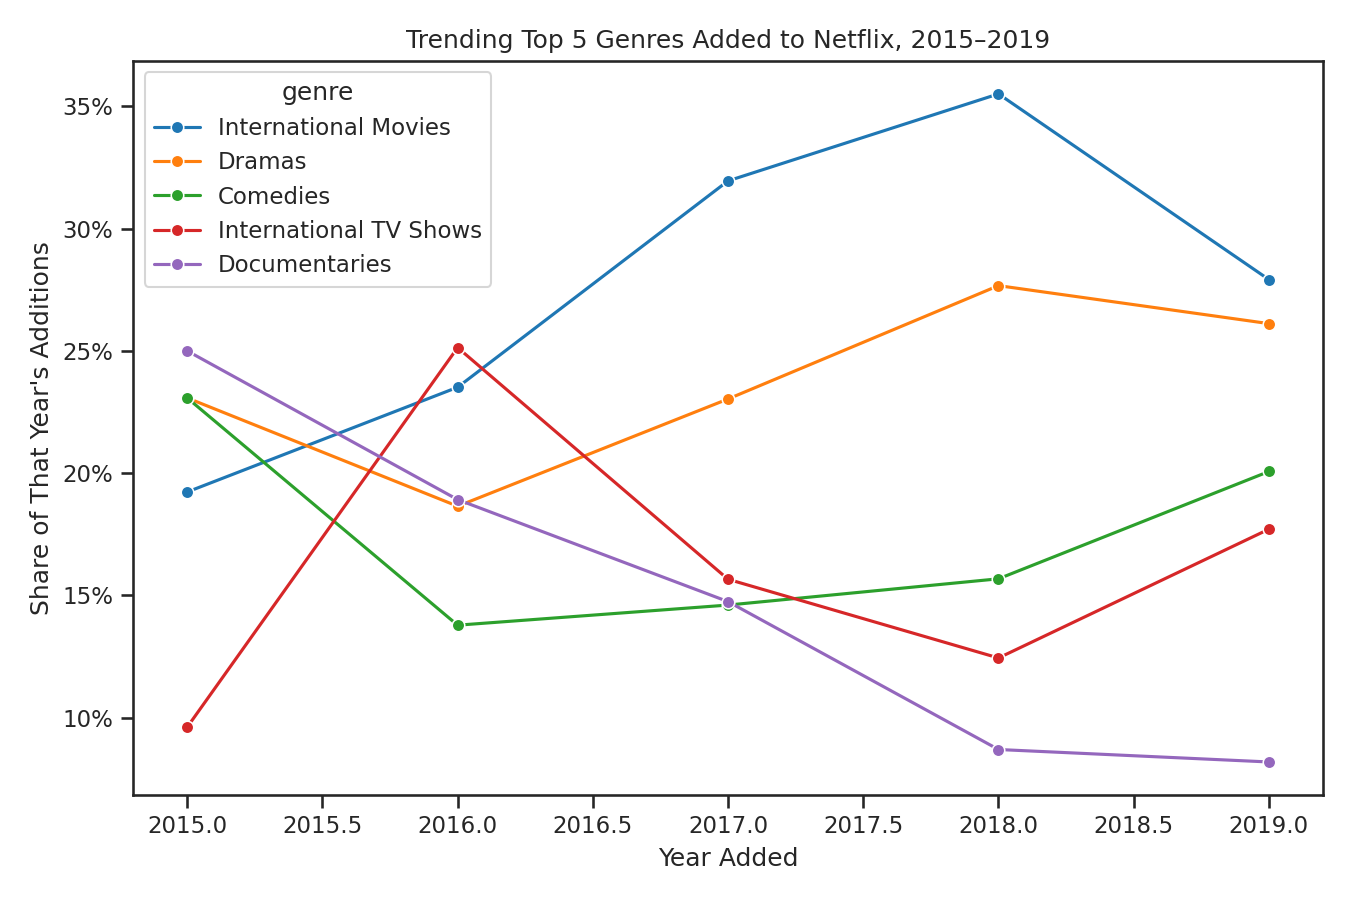

In [1]:
top5 = df_genres['genre'].value_counts().head(5).index.tolist()

trend = df_genres[
    (df_genres['genre'].isin(top5)) &
    (df_genres['year_added'] >= 2015) &
    (df_genres['year_added'] <= 2019)
]
pivot = trend.groupby(['year_added', 'genre']).size().unstack(fill_value=0)
pivot_pct = (pivot.div(pivot.sum(axis=1), axis=0) * 100)[top5]

fig, ax = plt.subplots(figsize=(9, 6))
sns.lineplot(data=pivot_pct, dashes=False, legend='full', palette='tab10', marker='o', ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_title("Trending Top 5 Genres Added to Netflix, 2015–2019")
ax.set_xlabel('Year Added')
ax.set_ylabel("Share of That Year's Additions")
plt.tight_layout()
plt.show()

### Insights

- **International Movies'** share of new additions climbed steadily from 19% of new titles in 2015 to a peak of 36% in 2018, reflecting Netflix's well-documented push into global content during that period, before settling back to 28% in 2019.
- **Documentaries'** share fell consistently, from 25% of new additions in 2015 down to about 8% by 2019 — even as the catalog overall grew far larger, documentaries became a smaller slice of what's new.
- **Dramas** stayed the most stable of the top 5, holding between roughly 23–28% of new additions every year — a reliable, evergreen category Netflix keeps investing in regardless of other shifts.